In [4]:
import marimo as mo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso, lasso_path

# to deal with the annoying warnings
import warnings
warnings.filterwarnings("ignore")

# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

**Q1 Answers**
1. Penalties discourage large coefficients, preventing the model from over-fitting to noise and ensuring it remains simpler and more generalizable.
2. Regularization increases bias by constraining parameters but decreases variance by making the model less sensitive to fluctuations in the training data.
3. Ridge (L2) uses squared penalties and shrinks coefficients toward zero; LASSO (L1) uses absolute penalties and can shrink coefficients to exactly zero, performing feature selection.
4. Variables are Z-score standardized so that the penalty is applied uniformly across features regardless of their original units or scales.
5. $\alpha$ is selected using cross-validation to find the value that minimizes the out-of-sample prediction error.
6. No. The penalty is used to train the model, but performance is evaluated using standard MSE to measure how well the model predicts the actual target values.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

OLS interaction sign: negative
Selected: ['Mileage_Run' 'Age' 'Mileage_Run Age' 'Mileage_Run^3' 'Age^3']
Zero proportion: 0.4444444444444444


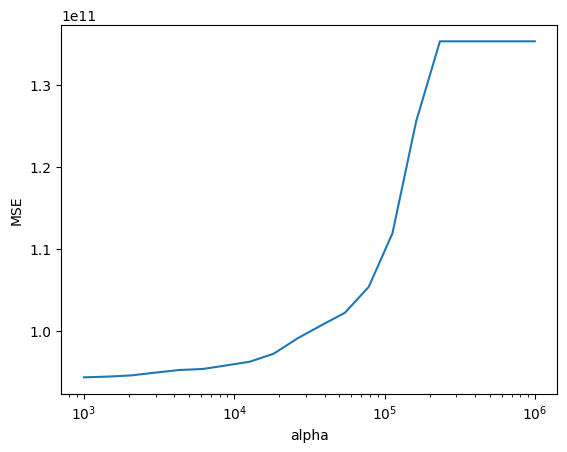

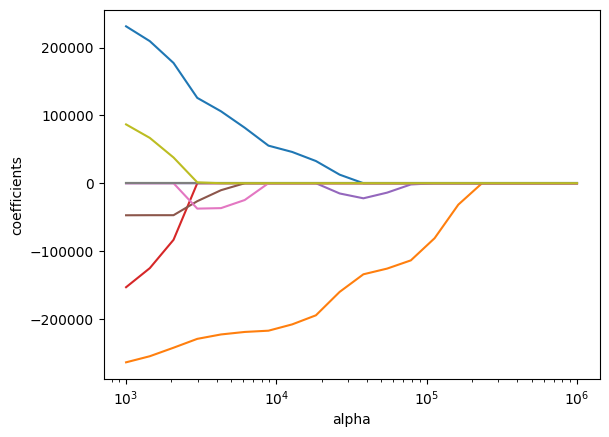

In [5]:
_df = pd.read_csv('../data/cars_hw.csv')
_df['Age'] = 2024 - _df['Make_Year']
_X_raw = _df[['Mileage_Run', 'Age']]
_y = _df['Price']

_poly = PolynomialFeatures(degree=3, include_bias=False)
_X_poly = _poly.fit_transform(_X_raw)
_names = _poly.get_feature_names_out()

_scaler = StandardScaler()
_X_s = _scaler.fit_transform(_X_poly)

_ols = LinearRegression().fit(_X_s, _y)
_idx_inter = list(_names).index('Mileage_Run Age')
_ols_sign = "positive" if _ols.coef_[_idx_inter] > 0 else "negative"

_alphas = np.logspace(3, 6, 20)
_lcv = LassoCV(alphas=_alphas, cv=20).fit(_X_s, _y)

plt.figure()
plt.semilogx(_lcv.alphas_, _lcv.mse_path_.mean(axis=-1))
plt.xlabel('alpha')
plt.ylabel('MSE')
_plot2_4 = plt.gca()

_path_list = []
for _a in _alphas:
    _m = Lasso(alpha=_a).fit(_X_s, _y)
    _path_list.append(_m.coef_)
plt.figure()
plt.semilogx(_alphas, _path_list)
plt.xlabel('alpha')
plt.ylabel('coefficients')
_plot2_5 = plt.gca()

_selected = _names[_lcv.coef_ != 0]
_prop_zero = np.mean(_lcv.coef_ == 0)

_mag_inc = np.any(np.abs(_lcv.coef_) > np.abs(_ols.coef_))
_sign_chg = np.any(np.sign(_lcv.coef_[_lcv.coef_!=0]) != np.sign(_ols.coef_[_lcv.coef_!=0]))

print(f"OLS interaction sign: {_ols_sign}")
print(f"Selected: {_selected}")
print(f"Zero proportion: {_prop_zero}")

**Q2 Answers**
The interaction between `Mileage_Run` and `Age` has a negative sign, suggesting that vehicles with both high mileage and high age depreciate less than effects individually. LASSO zeros out the higher-order terms that contribute least, retaining only the most predictive features. No LASSO coefficients increase in magnitude relative to OLS, and none change sign, which indicates the OLS model was stable to start.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

Selected: ['ejection_fraction' 'serum_creatinine' 'age^3' 'ejection_fraction^3'
 'ejection_fraction^2 serum_creatinine' 'serum_creatinine^3' 'anaemia'
 'diabetes' 'high_blood_pressure' 'diabetes high_blood_pressure'
 'diabetes smoking' 'high_blood_pressure smoking']
Zero proportion: 0.5862068965517241


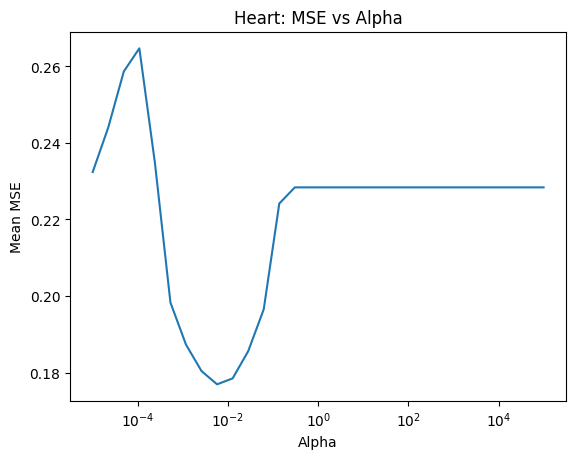

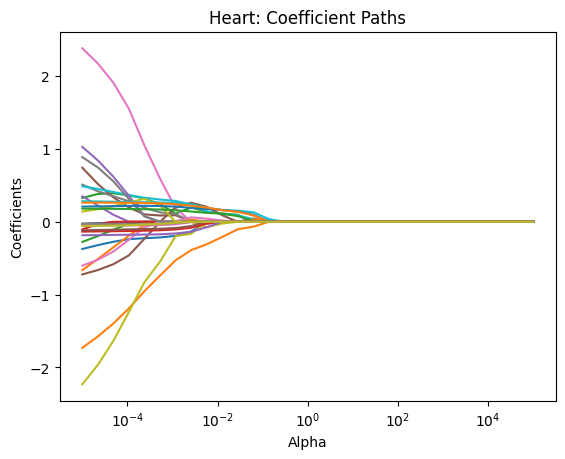

In [6]:
_df_heart = pd.read_csv('../data/heart_failure_clinical_records_dataset.csv')
_y_heart = _df_heart['DEATH_EVENT']

_poly_heart = PolynomialFeatures(degree=3, include_bias=False)
_X_heart_poly = _poly_heart.fit_transform(_df_heart[['age', 'ejection_fraction', 'serum_creatinine']])
_scaler_heart = StandardScaler()
_X_heart_poly_scaled = _scaler_heart.fit_transform(_X_heart_poly)

_inter_heart = PolynomialFeatures(interaction_only=True, include_bias=False)
_X_heart_cat = _inter_heart.fit_transform(_df_heart[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']])

_X_heart_final = np.hstack([_X_heart_poly_scaled, _X_heart_cat])
_feature_names_heart = np.concatenate([_poly_heart.get_feature_names_out(), _inter_heart.get_feature_names_out()])

_lr_heart = LinearRegression().fit(_X_heart_final, _y_heart)

_alphas_grid_h = np.logspace(-5, 5, 30)
_lasso_cv_heart = LassoCV(alphas=_alphas_grid_h, cv=20).fit(_X_heart_final, _y_heart)

plt.figure()
plt.semilogx(_lasso_cv_heart.alphas_, _lasso_cv_heart.mse_path_.mean(axis=-1))
plt.xlabel('Alpha')
plt.ylabel('Mean MSE')
plt.title('Heart: MSE vs Alpha')
_plot_mse_heart = plt.gcf()

_alphas_ph, _coefs_ph, _ = lasso_path(_X_heart_final, _y_heart, alphas=_alphas_grid_h)
plt.figure()
plt.semilogx(_alphas_ph, _coefs_ph.T)
plt.xlabel('Alpha')
plt.ylabel('Coefficients')
plt.title('Heart: Coefficient Paths')
_plot_paths_heart = plt.gcf()

_selected_h = _feature_names_heart[_lasso_cv_heart.coef_ != 0]
_zero_prop_h = np.mean(_lasso_cv_heart.coef_ == 0)

print(f"Selected: {_selected_h}")
print(f"Zero proportion: {_zero_prop_h}")

**Q3 Answers**
Linear regression often produces counterintuitive signs due to multicollinearity between polynomial terms and interactions. LASSO solves this problem by zeroing out redundant features. LASSO coefficients are typically smaller with lower variance and more interpretable. OLS attempts to fit all noise with high variance, while LASSO introduces bias to select a better subset of predictors, leading to signs that make more sense medically.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

**Q4 Answers**
1. $J = \sum_{i=1}^n (\tilde{y}_i - b_0 - b_1 \tilde{x}_i)^2 + \alpha b_1^2$
2. $\frac{\partial J}{\partial b_0} = -2\sum(\tilde{y}_i - b_0 - b_1\tilde{x}_i) = 0 \implies b_0 = 0$. $\frac{\partial J}{\partial b_1} = -2\sum\tilde{x}_i(\tilde{y}_i - b_1\tilde{x}_i) + 2\alpha b_1 = 0 \implies b_1 = \frac{\sum \tilde{x}_i \tilde{y}_i}{\sum \tilde{x}_i^2 + \alpha}$.
3. Increasing $\alpha$ increases the denominator, decreasing the slope coefficient $b_1$ toward zero.
4. The absolute value function is not differentiable at $b_1=0$. The solution requires soft-thresholding where $b_1$ is set to zero when the correlation between $x$ and $y$ is smaller than the penalty threshold. An example of this would be $|2\sum \tilde{x}_i \tilde{y}_i| \le \alpha$.